# 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 2. Load Dataset

In [13]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 3. Data Cleaning

In [14]:
# Drop customerID (not useful)
df = df.drop("customerID", axis=1)

In [15]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [16]:
# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [17]:
# Convert target column to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 4. Encode Categorical Variables

In [18]:
# Better approach: One-Hot Encoding (instead of LabelEncoder)
df = pd.get_dummies(df, drop_first=True)

# 5. Split Data

In [19]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Feature Scaling (for Logistic Regression only)

In [21]:
scaler = StandardScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Logistic Regression (Baseline)

In [23]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [25]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8415846443979436


# 8. Random Forest (Advanced Model)

In [26]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]


In [28]:
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.826492546952905


# 9. Confusion Matrix

In [29]:
cm = confusion_matrix(y_test, y_pred_rf)

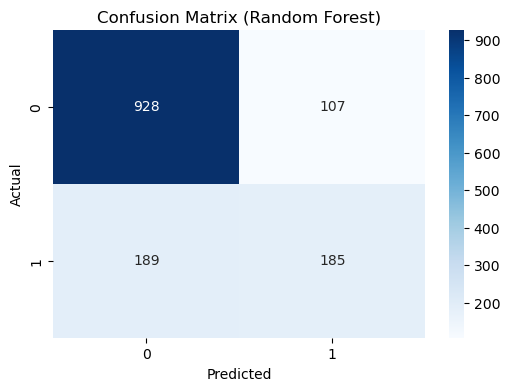

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 10. ROC Curve

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

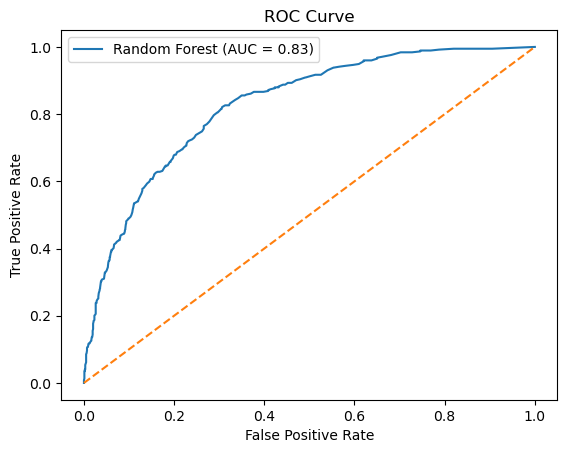

In [32]:
plt.figure()
plt.plot(fpr, tpr, label="Random Forest (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob_rf)))
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 11. Feature Importance

In [33]:
importances = rf.feature_importances_
features = X.columns

In [34]:
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

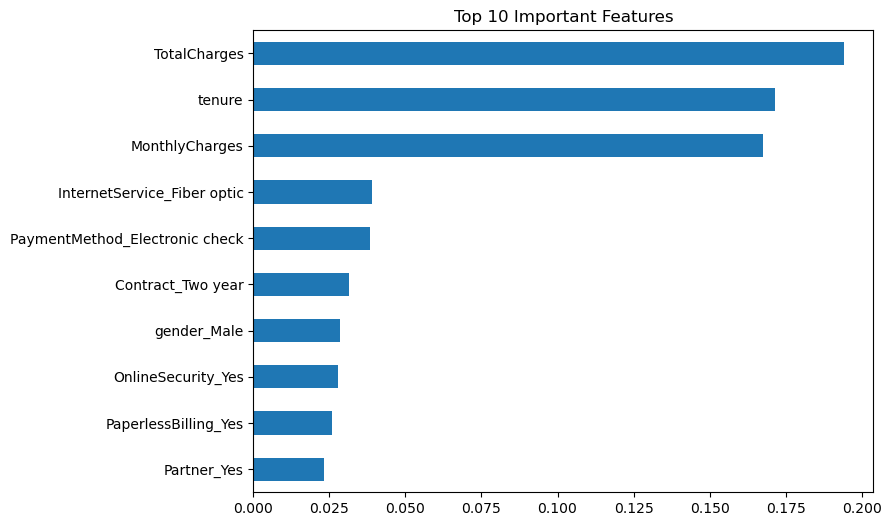

In [35]:
plt.figure(figsize=(8,6))
feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()